# Tube Detection Step By Step - Cam151

Version completa derivada de `tube_detection_step_by_step_cam152.ipynb`, apuntando a `cam_151_202604022.jpeg` y `manual_rois/cam_151_202604022_rois.toml`.

Esta camara **no** requiere espejo horizontal â€” `MIRROR_IN_BACKEND = False` siempre.


In [6]:
from pathlib import Path
import sys
import json
import math
import tomllib
import importlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

candidates = [ROOT] + list(ROOT.parents)
ROOT = None
for base in candidates:
    if (base / 'src').exists() and (base / 'test_images').exists():
        ROOT = base
        break
if ROOT is None:
    raise RuntimeError('Cannot locate project root (expected src/ and test_images/).')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.cam151_ref_detection.homography_preview import build_homography_preview
from src.cam151_ref_detection.roi_store import load_rois
from src.cam151_ref_detection import tube_detection_preview as tube_preview

tube_preview = importlib.reload(tube_preview)

build_tube_detection_preview = tube_preview.build_tube_detection_preview
_pick_detection_roi = tube_preview._pick_detection_roi
_warp_detection_roi = tube_preview._warp_detection_roi
_estimate_stack_band = tube_preview._estimate_stack_band
_normalize_01 = tube_preview._normalize_01
_smooth_1d = tube_preview._smooth_1d
_estimate_dominant_period = tube_preview._estimate_dominant_period
_find_local_peaks_1d = tube_preview._find_local_peaks_1d
_find_best_periodic_peak_run = tube_preview._find_best_periodic_peak_run
_median_period = tube_preview._median_period
_fill_missing_seams = tube_preview._fill_missing_seams
_extend_periodic_seams = tube_preview._extend_periodic_seams
_extend_centers_with_support = tube_preview._extend_centers_with_support
_smooth_x_positions = tube_preview._smooth_x_positions

ARTIFACT_ROOT = ROOT / 'artifacts' / 'notebook_step_by_step_cam151'
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
print(ROOT)



c:\Users\luis_\Desktop\tenaris_cam_152


## 1. Elegir Imagen

La notebook trabaja por defecto con `cam_151_202604022.jpeg`.

Cambiar `IMG_NAME` a cualquier otra imagen `cam_151*` disponible en `test_images/`.

No se aplica mirror — la imagen cam_151 se procesa tal cual.

Tambien puedes elegir una corrida guardada del historial:

- poner `USE_HISTORY_SELECTOR = True` para abrir un picker local;
- poner `USE_HISTORY_FOLDER_PICKER = True` para escoger directamente una carpeta del historial;
- o fijar `NOTEBOOK_HISTORY_SELECTION_ID` con un `run_id`, folder o artefacto historico.

Regla actual:

- en esta notebook de cam151, el default abre sobre el baseline actual separado;
- la app del MVP sigue usando el baseline congelado del 22 de abril;
- la base elegida se copia a un TOML temporal por corrida para que no se reescriba accidentalmente;
- eso solo cambia si pones un override explicito.


In [ ]:
USE_HISTORY_SELECTOR = False
USE_HISTORY_FOLDER_PICKER = False
NOTEBOOK_HISTORY_SELECTION_ID = None  # Ejemplos: '20260427_163748', 'artifacts/capture_history/20260427_163748' o 'backend_current_pair_alt.json'
NOTEBOOK_HISTORY_SELECTION = None
USE_HISTORY_SELECTION_ROI = False
ROI_PATH_OVERRIDE = None
PREFER_CURRENT_DEFAULT_ROI = True

DEFAULT_IMG_NAME = 'cam_151_202604022.jpeg'
FROZEN_CAMERA_ROI_PATH = ROOT / 'manual_rois' / '_frozen_defaults' / 'cam_151_202604022_rois.toml'
CURRENT_CAMERA_ROI_PATH = ROOT / 'manual_rois' / '_current_defaults' / 'cam_151_current_default_rois.toml'
IMG_NAME = DEFAULT_IMG_NAME
IMG_PATH = ROOT / 'test_images' / IMG_NAME
if not IMG_PATH.exists():
    raise FileNotFoundError(f'No existe la imagen cam151: {IMG_PATH}')

ROI_DIR = ROOT / 'manual_rois'
ROI_DIR.mkdir(parents=True, exist_ok=True)
ROI_RUNTIME_DIR = ARTIFACT_ROOT / '_roi_runtime'
ROI_RUNTIME_DIR.mkdir(parents=True, exist_ok=True)


def uses_april_22_baseline(image_name: str) -> bool:
    return Path(image_name).stem.lower() == 'cam_151_202604022'


def pick_default_roi_template(image_name: str) -> Path:
    if PREFER_CURRENT_DEFAULT_ROI:
        return CURRENT_CAMERA_ROI_PATH
    return FROZEN_CAMERA_ROI_PATH if uses_april_22_baseline(image_name) else CURRENT_CAMERA_ROI_PATH


def resolve_roi_path(root, image_name):
    stem = Path(image_name).stem
    candidates = [
        root / 'manual_rois' / f'{stem}_rois.toml',
        root / 'manual_rois' / f'{stem}_rois.json',
        root / 'artifacts' / 'manual_rois' / f'{stem}_rois.toml',
        root / 'artifacts' / 'manual_rois' / f'{stem}_rois.json',
        root / 'artifacts' / 'roi_exports' / f'{stem}_rois.toml',
        root / 'artifacts' / 'roi_exports' / f'{stem}_rois.json',
    ]
    downloads_dirs = [Path.home() / 'Downloads']
    root_parts = ROOT.parts
    if (
        len(root_parts) >= 5
        and root_parts[1].lower() == 'mnt'
        and root_parts[2].lower() == 'c'
        and root_parts[3].lower() == 'users'
    ):
        downloads_dirs.append(Path(*root_parts[:5]) / 'Downloads')
    seen_downloads = set()
    for downloads_dir in downloads_dirs:
        downloads_key = str(downloads_dir).lower()
        if downloads_key in seen_downloads or not downloads_dir.exists():
            continue
        seen_downloads.add(downloads_key)
        candidates.extend(downloads_dir.glob(f'{stem}_rois_export*.toml'))
        candidates.extend(downloads_dir.glob(f'{stem}_rois_export*.json'))
        candidates.extend(downloads_dir.glob(f'{image_name}_rois_export*.toml'))
        candidates.extend(downloads_dir.glob(f'{image_name}_rois_export*.json'))

    existing = [c for c in candidates if c.exists()]
    if existing:
        return max(existing, key=lambda c: c.stat().st_mtime)
    return candidates[0]


if NOTEBOOK_HISTORY_SELECTION_ID or USE_HISTORY_SELECTOR or USE_HISTORY_FOLDER_PICKER:
    import importlib
    import src.cam151_ref_detection.notebook_history as notebook_history

    notebook_history = importlib.reload(notebook_history)
    pick_notebook_history_folder_selection = notebook_history.pick_notebook_history_folder_selection
    pick_notebook_history_selection = notebook_history.pick_notebook_history_selection
    resolve_notebook_history_selection = notebook_history.resolve_notebook_history_selection

    if NOTEBOOK_HISTORY_SELECTION_ID:
        NOTEBOOK_HISTORY_SELECTION = resolve_notebook_history_selection('151', NOTEBOOK_HISTORY_SELECTION_ID)
    elif USE_HISTORY_FOLDER_PICKER:
        NOTEBOOK_HISTORY_SELECTION = pick_notebook_history_folder_selection('151', title='Seleccionar folder de historial para notebook cam151')
    else:
        NOTEBOOK_HISTORY_SELECTION = pick_notebook_history_selection('151', title='Seleccionar historial para notebook cam151')

    if NOTEBOOK_HISTORY_SELECTION is not None:
        IMG_PATH = NOTEBOOK_HISTORY_SELECTION.image_path
        IMG_NAME = IMG_PATH.name
        print('Notebook history selection =', NOTEBOOK_HISTORY_SELECTION.selection_id)
    else:
        print('Sin seleccion de historial; se conserva la imagen default.')


DEFAULT_CAMERA_ROI_PATH = pick_default_roi_template(IMG_NAME)

if ROI_PATH_OVERRIDE:
    ROI_PATH = Path(ROI_PATH_OVERRIDE)
elif NOTEBOOK_HISTORY_SELECTION is not None and USE_HISTORY_SELECTION_ROI:
    ROI_PATH = NOTEBOOK_HISTORY_SELECTION.roi_path
else:
    ROI_PATH = ROI_RUNTIME_DIR / f"{Path(IMG_NAME).stem}__default_runtime.toml"
    if ROI_PATH.exists():
        print('Usando ROI runtime existente; no se sobreescribe:', ROI_PATH)
    else:
        if not DEFAULT_CAMERA_ROI_PATH.exists():
            raise FileNotFoundError(f'No existe el ROI default de cam151: {DEFAULT_CAMERA_ROI_PATH}')
        import shutil
        shutil.copyfile(DEFAULT_CAMERA_ROI_PATH, ROI_PATH)

OUT_DIR = ARTIFACT_ROOT / Path(IMG_NAME).stem
OUT_DIR.mkdir(parents=True, exist_ok=True)


# Cam151 nunca usa mirror.
MIRROR_IN_BACKEND = False

print('IMG_PATH =', IMG_PATH)
print('FROZEN_CAMERA_ROI_PATH =', FROZEN_CAMERA_ROI_PATH)
print('CURRENT_CAMERA_ROI_PATH =', CURRENT_CAMERA_ROI_PATH)
print('PREFER_CURRENT_DEFAULT_ROI =', PREFER_CURRENT_DEFAULT_ROI)
print('DEFAULT_CAMERA_ROI_PATH =', DEFAULT_CAMERA_ROI_PATH)
print('ROI_PATH =', ROI_PATH)
print('OUT_DIR =', OUT_DIR)
print('MIRROR_IN_BACKEND =', MIRROR_IN_BACKEND)


In [ ]:
def show_bgr(img_or_path, title=None, figsize=(8, 12)):
    if isinstance(img_or_path, (str, Path)):
        img = cv2.imread(str(img_or_path), cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(img_or_path)
    else:
        img = img_or_path
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


def draw_manual_annotations(image_bgr, rois, points, lines):
    vis = image_bgr.copy()

    for roi in rois:
        x1, y1, x2, y2 = [int(round(v)) for v in roi.get('xyxy', [0, 0, 0, 0])]
        note = str(roi.get('note') or roi.get('id') or 'roi')
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(vis, note[:30], (x1 + 6, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2, cv2.LINE_AA)

    for line in lines:
        pts = line.get('points') or line.get('xyxy')
        if pts is None and all(key in line for key in ('x1', 'y1', 'x2', 'y2')):
            pts = [line['x1'], line['y1'], line['x2'], line['y2']]
        if pts is None:
            continue
        if isinstance(pts, list) and len(pts) == 4 and isinstance(pts[0], (int, float)):
            x1, y1, x2, y2 = [int(round(v)) for v in pts]
        else:
            (x1, y1), (x2, y2) = pts
            x1, y1, x2, y2 = map(lambda v: int(round(v)), [x1, y1, x2, y2])
        label = str(line.get('label') or line.get('id') or 'line')
        cv2.line(vis, (x1, y1), (x2, y2), (255, 210, 0), 2, cv2.LINE_AA)
        cv2.putText(vis, label[:30], (x1 + 4, max(18, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 210, 0), 1, cv2.LINE_AA)

    for point in points:
        x = int(round(point.get('x', 0)))
        y = int(round(point.get('y', 0)))
        label = str(point.get('label') or point.get('kind') or point.get('id') or 'pt')
        cv2.circle(vis, (x, y), 5, (255, 0, 255), -1, cv2.LINE_AA)
        cv2.putText(vis, label[:30], (x + 6, max(18, y - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 255), 1, cv2.LINE_AA)

    return vis

HOMOGRAPHY_CORNER_LABELS = ('top_02', 'top_03', 'base_02', 'base_01')

def label_key(value):
    return ' '.join(str(value or '').strip().lower().split())

def normalize_homography_src_points(value):
    if not value:
        return None
    if len(value) != 4:
        raise RuntimeError(f'src_points_override debe tener 4 puntos en {ROI_PATH}')
    src_points = []
    for point in value:
        if isinstance(point, dict):
            src_points.append((float(point['x']), float(point['y'])))
        else:
            src_points.append((float(point[0]), float(point[1])))
    return src_points

def load_homography_src_points_from_roi_file(path):
    path = Path(path)
    if not path.exists():
        return None
    if path.suffix.lower() == '.toml':
        raw = tomllib.loads(path.read_text(encoding='utf-8'))
    else:
        raw = json.loads(path.read_text(encoding='utf-8'))
    return normalize_homography_src_points(raw.get('src_points_override'))

def resolve_homography_src_points(data, points):
    override = normalize_homography_src_points(data.get('src_points_override'))
    if override:
        return override

    override = load_homography_src_points_from_roi_file(ROI_PATH)
    if override:
        return override

    by_label = {label_key(point.get('label')): point for point in points}
    missing = [label for label in HOMOGRAPHY_CORNER_LABELS if label_key(label) not in by_label]
    if missing:
        raise RuntimeError(
            f'Faltan puntos de homografia {missing} en {ROI_PATH}. '
            'Guarda/exporta desde la app web o conserva src_points_override en el TOML cam152.'
        )
    return [(float(by_label[label_key(label)]['x']), float(by_label[label_key(label)]['y'])) for label in HOMOGRAPHY_CORNER_LABELS]

def homography_dst_rect_for_src_points(src_points):
    tl, tr, bl, br = src_points
    top_width = math.hypot(tr[0] - tl[0], tr[1] - tl[1])
    bottom_width = math.hypot(br[0] - bl[0], br[1] - bl[1])
    left_height = math.hypot(bl[0] - tl[0], bl[1] - tl[1])
    right_height = math.hypot(br[0] - tr[0], br[1] - tr[1])
    width = max(240, int(round(max(top_width, bottom_width))))
    height = max(320, int(round(max(left_height, right_height))))
    return (0.0, 0.0, float(width - 1), float(height - 1))



## 2. Cargar Imagen Y Anotaciones Manuales

Aqui cargamos la imagen original y el archivo de anotaciones exportado desde la app web.

Las anotaciones manuales son la base de dos cosas:
- la homografia,
- la ROI inferior que se usa para sembrar la deteccion de tubos.

Si el archivo no existe todavia para la imagen seleccionada, debes crearlo primero con:
- usar las celdas integradas de `warp_roi_picker_proc`, `ref_line_picker_proc` y `scale_line_picker_proc`
- los pickers se abren desde la notebook cuando se ejecutan las celdas correspondientes
- guardar ROIs / puntos / lineas para esa imagen


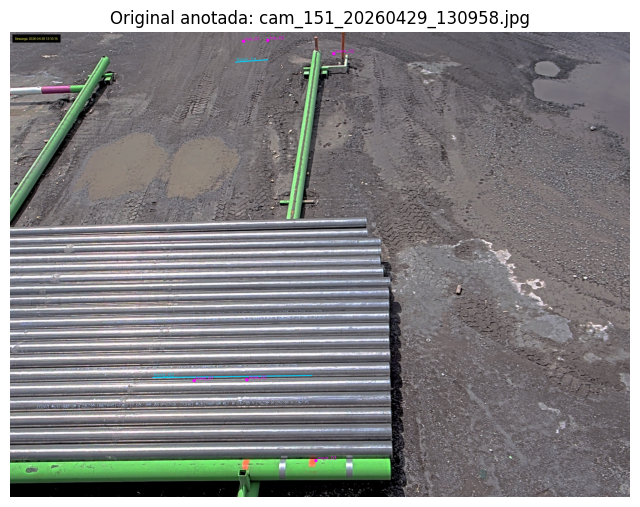

ROIs: 0 | points: 6 | lines: 4
SOURCE_W/H = 2048 1536


In [ ]:
image_bgr = cv2.imread(str(IMG_PATH), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise FileNotFoundError(IMG_PATH)

SOURCE_W = int(image_bgr.shape[1])
SOURCE_H = int(image_bgr.shape[0])


def line_is_warp_space(line):
    return str(line.get('kind') or '') == 'warp_scale_ref' or str(line.get('coordinate_space') or '') == 'warp'


# Cam151 no usa mirror â€” estas funciones son no-op pero se mantienen para consistencia.
def mirror_source_x(x, width=SOURCE_W):
    return float(width - 1 - float(x))


def mirror_point_for_processing(point, width=SOURCE_W):
    mirrored = dict(point)
    mirrored['x'] = int(round(mirror_source_x(point.get('x', 0), width)))
    return mirrored


def mirror_line_for_processing(line, width=SOURCE_W):
    if line_is_warp_space(line):
        return dict(line)
    mirrored = dict(line)
    mirrored['x1'] = int(round(mirror_source_x(line.get('x1', 0), width)))
    mirrored['x2'] = int(round(mirror_source_x(line.get('x2', 0), width)))
    return mirrored


def mirror_roi_for_processing(roi, width=SOURCE_W):
    if roi is None:
        return None
    mirrored = dict(roi)
    x1, y1, x2, y2 = [int(round(float(v))) for v in roi.get('xyxy', [0, 0, 0, 0])[:4]]
    mx1 = int(round(mirror_source_x(x2, width)))
    mx2 = int(round(mirror_source_x(x1, width)))
    mirrored['xyxy'] = [min(mx1, mx2), y1, max(mx1, mx2), y2]
    return mirrored


def source_xy_for_processing(x_src, y_src):
    # MIRROR_IN_BACKEND es False para cam151 â€” sin transformacion.
    return float(x_src), float(y_src)


data = load_rois(ROI_PATH)
rois = data.get('rois', [])
points = data.get('points', [])
lines = data.get('lines', [])

source_lines = [line for line in lines if not line_is_warp_space(line)]
annotated = draw_manual_annotations(image_bgr, rois, points, source_lines)
show_bgr(annotated, f'Original anotada: {IMG_NAME}', figsize=(8, 12))

# MIRROR_IN_BACKEND = False â€” se usa la imagen directamente sin espejo.
processing_image_bgr = image_bgr
processing_rois = rois
processing_points = points
processing_lines = source_lines

print('ROIs:', len(rois), '| points:', len(points), '| lines:', len(lines))
print('SOURCE_W/H =', SOURCE_W, SOURCE_H)

if not ROI_PATH.exists():
    display(Markdown(
        f'**ROI file missing**: `{ROI_PATH}`\n\n'
        f'1. Ejecuta las celdas integradas de picker desde la notebook.\n'
        f'2. Usa el link mostrado por la celda del picker.\n'
        f'3. Selecciona `{IMG_NAME}` y guarda ROIs / puntos / lineas.\n'
        f'4. Vuelve a correr esta celda.'
    ))
    raise RuntimeError(f'Missing ROI annotations for {IMG_NAME}: {ROI_PATH}')


## 1b. Definir Puntos de Homografia (browser local)

Coloca los **4 puntos** sobre la imagen original que definen la homografia. Se guardan como `src_points_override` en el TOML.

**Orden de los puntos:**
1. **TL** - P1 arriba-izq
2. **TR** - P2 arriba-der
3. **BL** - P3 abajo-izq
4. **BR** - P4 abajo-der

**Controles:** click izquierdo coloca el siguiente punto, arrastrar mueve un punto existente, rueda hace zoom, Shift/click medio/click derecho arrastra la imagen, Enter confirma y Esc cancela.


In [ ]:
# -- Picker de homografia (browser local; evita Tk bloqueado en Jupyter) --
import importlib
from src.cam151_ref_detection import hom_picker_proc as _hom_picker_proc
from src.cam151_ref_detection.roi_store import load_rois
from src.cam151_ref_detection.roi_store import _to_toml as _roi_to_toml
_hom_picker_proc = importlib.reload(_hom_picker_proc)
run_picker = _hom_picker_proc.run_picker
_H_LABELS = ('TL', 'TR', 'BL', 'BR')
_H_NAMES  = {'TL': 'P1 arriba-izq', 'TR': 'P2 arriba-der', 'BL': 'P3 abajo-izq', 'BR': 'P4 abajo-der'}
_existing_src = data.get('src_points_override')
if _existing_src and len(_existing_src) == 4:
    _pts_init = {lbl: list(xy) for lbl, xy in zip(_H_LABELS, _existing_src)}
    print('Puntos actuales:', {k: [round(v, 1) for v in vs] for k, vs in _pts_init.items()})
else:
    _pts_init = {}
    print('Sin puntos previos; coloca los 4 desde cero.')
print('Abriendo picker en el navegador local...')
RUN_PICKER = False
if RUN_PICKER:
    _result_pts = run_picker(processing_image_bgr, _pts_init, img_path=str(IMG_PATH), backend='web')
if RUN_PICKER and _result_pts is not None:
    _new_src = [[round(float(_result_pts[lbl][0]), 3), round(float(_result_pts[lbl][1]), 3)]
                for lbl in _H_LABELS]
    _roi_data_now = load_rois(ROI_PATH)
    _roi_data_now['src_points_override'] = _new_src
    # No tocar dst_rect_override: lo dejamos intacto para no perder el warp ROI
    # cuando el usuario re-ajusta solo TL/TR/BL/BR. Si cambian mucho los src_points,
    # vuelve a correr la celda del warp ROI para reajustar.
    from datetime import datetime as _dt_now_for_backup
    import shutil as _shutil_for_backup
    if ROI_PATH == DEFAULT_CAMERA_ROI_PATH and ROI_PATH.exists():
        _backup_dir = ROOT / 'manual_rois' / '_backups' / _dt_now_for_backup.now().strftime('%Y%m%d_%H%M%S')
        _backup_dir.mkdir(parents=True, exist_ok=True)
        _shutil_for_backup.copyfile(ROI_PATH, _backup_dir / ROI_PATH.name)
    ROI_PATH.write_text(_roi_to_toml(_roi_data_now), encoding='utf-8')
    data['src_points_override'] = _new_src
    homography_src_points = _new_src
    print('Guardado:')
    for lbl, xy in zip(_H_LABELS, _new_src):
        print(f'  {_H_NAMES[lbl]}: {[round(v, 1) for v in xy]}')
    print()
    print('Ahora corre la celda "3. Construir La Homografia".')
else:
    if _existing_src and len(_existing_src) == 4:
        homography_src_points = [[float(x), float(y)] for x, y in _existing_src]
        print('ESC/cancelado: se conservan los puntos de homografia anteriores:')
        for lbl, xy in zip(_H_LABELS, homography_src_points):
            print(f'  {_H_NAMES[lbl]}: {[round(v, 1) for v in xy]}')
    else:
        print('ESC/cancelado: no habia puntos anteriores guardados; coloca los 4 puntos para continuar.')


## 3. Construir La Homografia

`src_points_override` define los 4 puntos base de la homografia.

`dst_rect_override` es el ROI dentro del warp: el rectangulo en coordenadas del warp rectificado que se exporta desde la app y que aqui usamos como recorte final.


In [ ]:
homography_src_points = resolve_homography_src_points(data, points)

# ROI dentro del warp. Si existe en el TOML exportado, este rectangulo manda.
# Coordenadas: [x0, y0, x1, y1] en el espacio rectificado de la homografia.
warp_roi_rect = data.get('dst_rect_override')
if warp_roi_rect is None:
    warp_roi_rect = homography_dst_rect_for_src_points(homography_src_points)
homography_dst_rect = warp_roi_rect

homography = build_homography_preview(
    image_path=IMG_PATH,
    lines=lines,
    points=points,
    output_dir=OUT_DIR / '01_homography',
    src_points_override=homography_src_points,
    dst_rect_override=homography_dst_rect,
    flip_horizontal=MIRROR_IN_BACKEND,
    output_flip_horizontal=MIRROR_IN_BACKEND,
)


def build_final_output_transform(src_points, output_size, *, output_flip_horizontal=False):
    width, height = int(output_size[0]), int(output_size[1])
    transform = cv2.getPerspectiveTransform(
        np.float32(src_points),
        np.float32([
            [0, 0],
            [width - 1, 0],
            [0, height - 1],
            [width - 1, height - 1],
        ])
    )
    if output_flip_horizontal:
        output_flip = np.float32([
            [-1.0, 0.0, float(width - 1)],
            [0.0, 1.0, 0.0],
            [0.0, 0.0, 1.0],
        ])
        transform = output_flip @ transform
    return transform


final_transform = build_final_output_transform(
    homography.src_points,
    homography.output_size,
    output_flip_horizontal=MIRROR_IN_BACKEND,
)

print('homography_src_points =', homography_src_points)
print('warp_roi_rect / dst_rect_override =', warp_roi_rect)
print('mirror input/output =', MIRROR_IN_BACKEND)
print('src_points =', homography.src_points)
print('output_size =', homography.output_size)
print('overlay =', homography.overlay_path)
print('warp =', homography.warp_path)


homography_src_points = [(992.813, 116.674), (1154.209, 113.284), (819.618, 1411.319), (1256.392, 1410.187)]
warp_roi_rect / dst_rect_override = [-58.196, -162.469, 508.649, 1313.809]
mirror input/output = False
src_points = [(980.2852172851562, 61.80048751831055), (1174.8590087890625, 57.56094741821289), (757.8617553710938, 1435.3409423828125), (1332.452880859375, 1434.047607421875)]
output_size = (567, 1476)
overlay = c:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\artifacts\notebook_step_by_step_cam151\cam_151_20260429_130958\01_homography\homography_overlay.jpg
warp = c:\Users\luis_\Downloads\descarga_imagenes\cam151_ref_detection_clean\artifacts\notebook_step_by_step_cam151\cam_151_20260429_130958\01_homography\homography_warp.jpg


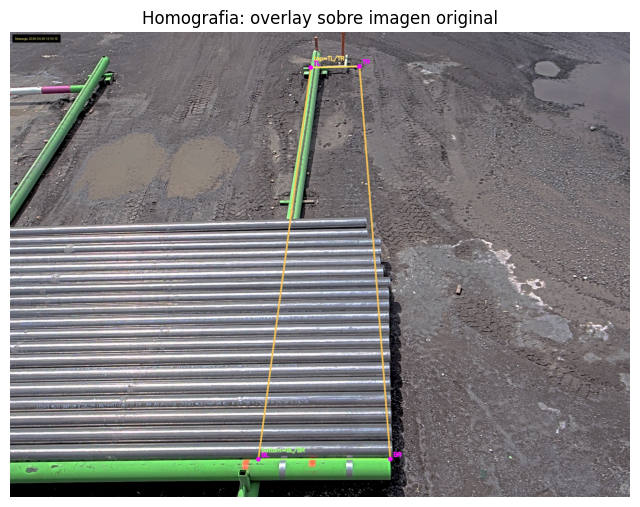

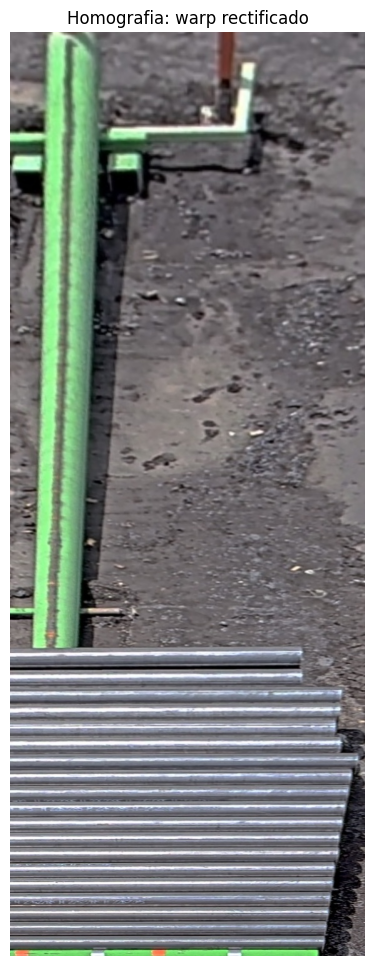

In [ ]:
show_bgr(homography.overlay_path, 'Homografia: overlay sobre imagen original', figsize=(8, 12))
show_bgr(homography.warp_path, 'Homografia: warp rectificado', figsize=(8, 12))


## 4. Elegir Y Proyectar La `tube ROI`

No detectamos tubos sobre todo el `warp`. Primero elegimos una ROI inferior anotada manualmente y la proyectamos al `warp`.

Luego la expandimos:
- hacia arriba, para incluir el paquete completo,
- hasta la derecha del `warp`, para no cortar las puntas.

In [ ]:
warp_bgr = cv2.imread(str(homography.warp_path), cv2.IMREAD_COLOR)
if warp_bgr is None:
    raise FileNotFoundError(homography.warp_path)


def warp_detection_roi_for_notebook(roi):
    if roi is None:
        return None
    x1, y1, x2, y2 = [float(v) for v in roi['xyxy']]
    roi_pts = np.float32([[[x1, y1]], [[x2, y1]], [[x2, y2]], [[x1, y2]]])
    warped = cv2.perspectiveTransform(roi_pts, final_transform).reshape(-1, 2)
    if warped.size == 0 or not np.all(np.isfinite(warped)):
        return None

    wx0 = int(np.floor(float(np.min(warped[:, 0]))))
    wy0 = int(np.floor(float(np.min(warped[:, 1]))))
    wx1 = int(np.ceil(float(np.max(warped[:, 0]))))
    wy1 = int(np.ceil(float(np.max(warped[:, 1]))))

    h_warp, w_warp = warp_bgr.shape[:2]
    raw_h = max(2, wy1 - wy0)
    expand_up = max(220, int(round(0.28 * float(h_warp))), int(round(8.0 * float(raw_h))))
    expand_down = max(16, int(round(1.5 * float(raw_h))))
    expand_x = 18

    wx0 = max(0, min(wx0 - expand_x, w_warp - 2))
    wx1 = w_warp
    wy0 = max(0, min(wy0 - expand_up, h_warp - 2))
    wy1 = max(wy0 + 2, min(wy1 + expand_down, h_warp))
    return (wx0, wy0, wx1, wy1)


if data.get('dst_rect_override'):
    selected_roi = None
    selected_roi_processing = None
    detection_roi = (0, 0, int(warp_bgr.shape[1]), int(warp_bgr.shape[0]))
    print('dst_rect_override activo; se analizara el warp recortado completo.')
    print('selected_roi =', selected_roi)
    print('selected_roi_processing =', selected_roi_processing)
    print('initial detection_roi =', detection_roi)
else:
    selected_roi = _pick_detection_roi(rois)
    selected_roi_processing = mirror_roi_for_processing(selected_roi) if MIRROR_IN_BACKEND else selected_roi
    detection_roi = warp_detection_roi_for_notebook(selected_roi_processing)
    print('selected_roi =', selected_roi)
    print('selected_roi_processing =', selected_roi_processing)
    print('initial detection_roi =', detection_roi)

    if detection_roi is not None:
        stack_band = _estimate_stack_band(warp_bgr, detection_roi[0], detection_roi[2])
        print('stack_band =', stack_band)
        if stack_band is not None:
            band_y0, band_y1, run, period = stack_band
            top_expand = max(220, int(round(13.0 * float(period or 22.0))))
            detection_roi = (
                int(detection_roi[0]),
                int(min(detection_roi[1], max(0, band_y0 - top_expand))),
                int(detection_roi[2]),
                int(max(detection_roi[3], band_y1)),
            )
    else:
        print('No hay ROI de tubos en el TOML; se usara el warp completo para continuar el paso a paso.')
        detection_roi = (0, 0, int(warp_bgr.shape[1]), int(warp_bgr.shape[0]))

print('expanded detection_roi =', detection_roi)


dst_rect_override activo; se analizara el warp recortado completo.
selected_roi = None
selected_roi_processing = None
initial detection_roi = (0, 0, 567, 1476)
expanded detection_roi = (0, 0, 567, 1476)


## 4b. Ajustar ROI de Deteccion sobre la Imagen Completa Warpeada (browser local)

Muestra la **imagen fuente completa transformada al plano del warp**, no solo el rectangulo TL/TR/BL/BR de homografia. En cam152 se muestra con el mismo espejo horizontal usado para analizar el warp.

Al confirmar, el rectangulo dibujado se convierte a coordenadas internas de `dst_rect_override`, se guarda en el TOML y el `warp_bgr` queda recortado a esa zona para seguir el analisis.

**Controles:** arrastrar con click izquierdo dibuja el rectangulo; arrastrar dentro del rectangulo lo mueve; rueda hace zoom; Shift/click medio/click derecho hace paneo; Enter confirma; Esc cancela.


In [ ]:
# -- ROI picker sobre la imagen COMPLETA en el plano del warp (browser local) --
# 1. Calcula la homografia base con TL/TR/BL/BR.
# 2. Proyecta TODA la imagen fuente al plano rectificado, no solo el cuadrilatero TL/TR/BL/BR.
# 3. El browser muestra ese warp extendido. En cam152 se ve con el mirror de salida.
# 4. Convierte el rectangulo de pantalla a dst_rect_override, guarda TOML y recorta warp_bgr.
import importlib
from src.cam151_ref_detection import warp_roi_picker_proc as _warp_roi_picker_proc
from src.cam151_ref_detection.roi_store import load_rois
from src.cam151_ref_detection.roi_store import _to_toml as _roi_to_toml
_warp_roi_picker_proc = importlib.reload(_warp_roi_picker_proc)
run_warp_roi_picker = _warp_roi_picker_proc.run_warp_roi_picker
build_full_warp_view = _warp_roi_picker_proc.build_full_warp_view
# Asegurar que homography_src_points refleja lo guardado mas recientemente.
homography_src_points = resolve_homography_src_points(data, points)
# Esta llamada construye la homografia base. Su warp_path sigue siendo el rectangulo
# TL/TR/BL/BR, pero aqui solo necesitamos la matriz para proyectar la imagen completa.
_hom_base = build_homography_preview(
    image_path=IMG_PATH,
    lines=lines,
    points=points,
    output_dir=OUT_DIR / '01_homography_base_for_full_view',
    src_points_override=homography_src_points,
    dst_rect_override=None,
    flip_horizontal=MIRROR_IN_BACKEND,
    output_flip_horizontal=MIRROR_IN_BACKEND,
)
# Warp extendido: usa las 4 esquinas de la imagen fuente y conserva todo lo que cae
# fuera del rectangulo TL/TR/BL/BR, incluyendo coordenadas negativas del plano.
_full_view = build_full_warp_view(
    image_path=IMG_PATH,
    homography_matrix=_hom_base.homography_matrix,
    output_dir=OUT_DIR / '01_homography_full_source',
    flip_horizontal=MIRROR_IN_BACKEND,
    output_flip_horizontal=MIRROR_IN_BACKEND,
)
_warp_full = _full_view.image_bgr
_full_h, _full_w = _warp_full.shape[:2]
_full_dst_rect = tuple(float(v) for v in _full_view.view_rect)
_output_mirrored = bool(_full_view.output_mirrored)
print(f'Warp extendido de imagen completa: {_full_w}x{_full_h} px')
print('Mirror de salida:', _output_mirrored)
print('Rango mostrado en coordenadas dst_rect:', [round(v, 3) for v in _full_dst_rect])
print('Archivo warp extendido:', _full_view.warp_path)
def _normalize_display_rect(rect, width, height):
    if not rect:
        return None
    x0, y0, x1, y1 = [float(v) for v in rect]
    x0, x1 = sorted((max(0.0, min(float(width), x0)), max(0.0, min(float(width), x1))))
    y0, y1 = sorted((max(0.0, min(float(height), y0)), max(0.0, min(float(height), y1))))
    if x1 - x0 < 5 or y1 - y0 < 5:
        return None
    return [x0, y0, x1, y1]
def _dst_rect_to_display_rect(rect, full_dst_rect, width, height, mirrored_output):
    if not rect:
        return None
    fx0, fy0, _fx1, _fy1 = full_dst_rect
    x0, y0, x1, y1 = [float(v) for v in rect]
    if mirrored_output:
        dx0 = float(width) - (x1 - fx0)
        dx1 = float(width) - (x0 - fx0)
    else:
        dx0 = x0 - fx0
        dx1 = x1 - fx0
    dy0 = y0 - fy0
    dy1 = y1 - fy0
    return _normalize_display_rect([dx0, dy0, dx1, dy1], width, height)
def _display_rect_to_dst_rect(rect, full_dst_rect, width, mirrored_output):
    fx0, fy0, _fx1, _fy1 = full_dst_rect
    x0, y0, x1, y1 = [float(v) for v in rect]
    if mirrored_output:
        dst_x0 = fx0 + float(width) - x1
        dst_x1 = fx0 + float(width) - x0
    else:
        dst_x0 = fx0 + x0
        dst_x1 = fx0 + x1
    dst_y0 = fy0 + y0
    dst_y1 = fy0 + y1
    return [round(float(dst_x0), 3), round(float(dst_y0), 3), round(float(dst_x1), 3), round(float(dst_y1), 3)]
_dst_current = data.get('dst_rect_override')
_dst_current_display = _dst_rect_to_display_rect(_dst_current, _full_dst_rect, _full_w, _full_h, _output_mirrored)
if _dst_current:
    print('dst_rect_override actual:', [round(float(v), 1) for v in _dst_current])
    if _dst_current_display:
        print('Rectangulo actual en pantalla:', [round(v, 1) for v in _dst_current_display])
    else:
        print('El dst_rect actual queda fuera del warp extendido visible; dibuja uno nuevo.')
else:
    print('No hay dst_rect_override definido.')
print('Abriendo picker web sobre la imagen completa warpeada...')
_new_rect_display = run_warp_roi_picker(
    _warp_full,
    _dst_current_display,
    img_path=str(_full_view.warp_path),
    backend='web',
)
if _new_rect_display is not None:
    _new_rect = _display_rect_to_dst_rect(_new_rect_display, _full_dst_rect, _full_w, _output_mirrored)
    # 1. Guardar en TOML.
    _roi_data_now = load_rois(ROI_PATH)
    _roi_data_now['dst_rect_override'] = _new_rect
    from datetime import datetime as _dt_now_for_backup
    import shutil as _shutil_for_backup
    if ROI_PATH == DEFAULT_CAMERA_ROI_PATH and ROI_PATH.exists():
        _backup_dir = ROOT / 'manual_rois' / '_backups' / _dt_now_for_backup.now().strftime('%Y%m%d_%H%M%S')
        _backup_dir.mkdir(parents=True, exist_ok=True)
        _shutil_for_backup.copyfile(ROI_PATH, _backup_dir / ROI_PATH.name)
    ROI_PATH.write_text(_roi_to_toml(_roi_data_now), encoding='utf-8')
    data['dst_rect_override'] = _new_rect
    print('ROI dibujado en pantalla:', [round(v, 1) for v in _new_rect_display])
    print('dst_rect_override guardado:', [round(v, 1) for v in _new_rect])
    # 2. Regenerar homography con el nuevo rect.
    homography = build_homography_preview(
        image_path=IMG_PATH,
        lines=lines,
        points=points,
        output_dir=OUT_DIR / '01_homography',
        src_points_override=homography_src_points,
        dst_rect_override=_new_rect,
        flip_horizontal=MIRROR_IN_BACKEND,
        output_flip_horizontal=MIRROR_IN_BACKEND,
    )
    final_transform = build_final_output_transform(
        homography.src_points,
        homography.output_size,
        output_flip_horizontal=MIRROR_IN_BACKEND,
    )
    # 3. Recargar warp_bgr. Este warp ya es la zona seleccionada.
    warp_bgr = cv2.imread(str(homography.warp_path), cv2.IMREAD_COLOR)
    if warp_bgr is None:
        raise FileNotFoundError(homography.warp_path)
    detection_roi = (0, 0, int(warp_bgr.shape[1]), int(warp_bgr.shape[0]))
    warp_crop = warp_bgr.copy()
    print(f'Nuevo warp_bgr seleccionado: {warp_bgr.shape[1]}x{warp_bgr.shape[0]} px')
    print(f'detection_roi actualizado al warp seleccionado completo: {detection_roi}')
    print(f'warp_crop: {warp_crop.shape[1]}x{warp_crop.shape[0]} px')
    # 4. Visualizar seleccion sobre la imagen completa warpeada y resultado final recortado.
    _vis = _warp_full.copy()
    x0r, y0r, x1r, y1r = [int(round(v)) for v in _new_rect_display]
    cv2.rectangle(_vis, (x0r, y0r), (x1r, y1r), (0, 204, 255), 2, cv2.LINE_AA)
    show_bgr(_vis, 'ROI seleccionado sobre imagen completa warpeada', figsize=(12, 7))
    show_bgr(warp_bgr, 'Warp recortado para analisis', figsize=(8, 12))
else:
    if _dst_current:
        print('ESC/cancelado: se conserva el dst_rect_override anterior:', [round(float(v), 1) for v in _dst_current])
        homography = build_homography_preview(
            image_path=IMG_PATH,
            lines=lines,
            points=points,
            output_dir=OUT_DIR / '01_homography',
            src_points_override=homography_src_points,
            dst_rect_override=_dst_current,
            flip_horizontal=MIRROR_IN_BACKEND,
            output_flip_horizontal=MIRROR_IN_BACKEND,
        )
        final_transform = build_final_output_transform(
            homography.src_points,
            homography.output_size,
            output_flip_horizontal=MIRROR_IN_BACKEND,
        )
        warp_bgr = cv2.imread(str(homography.warp_path), cv2.IMREAD_COLOR)
        if warp_bgr is None:
            raise FileNotFoundError(homography.warp_path)
        detection_roi = (0, 0, int(warp_bgr.shape[1]), int(warp_bgr.shape[0]))
        warp_crop = warp_bgr.copy()
        print(f'Warp anterior recargado: {warp_bgr.shape[1]}x{warp_bgr.shape[0]} px')
    else:
        print('ESC/cancelado: no habia dst_rect_override anterior; se conserva warp_bgr/detection_roi actual si ya existian.')


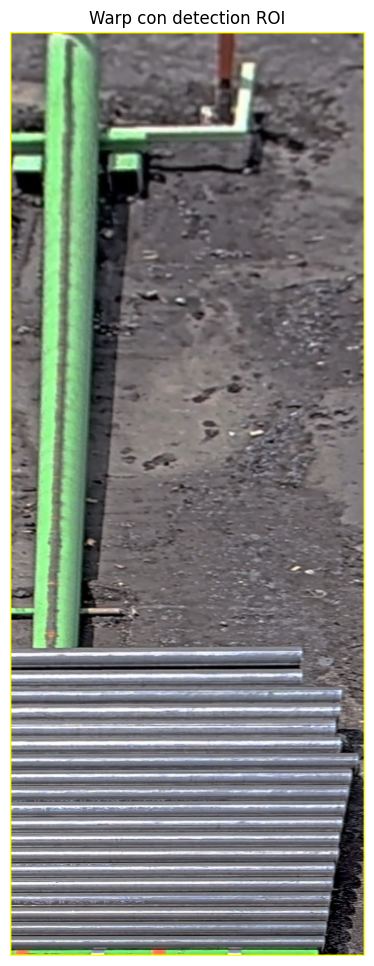

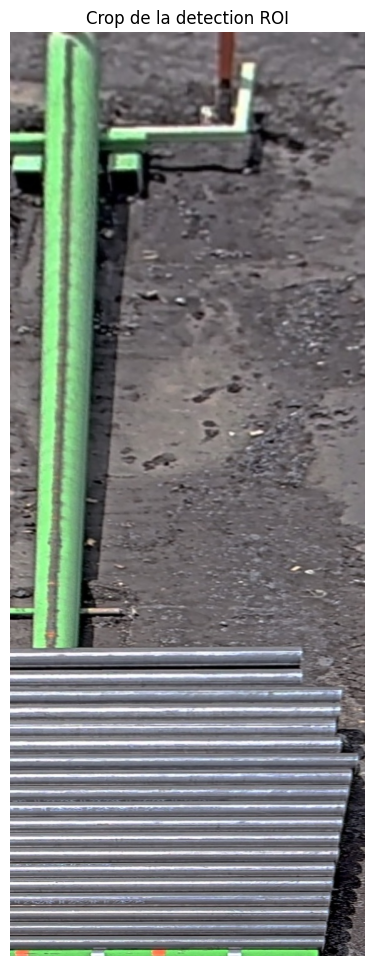

In [ ]:
warp_vis = warp_bgr.copy()
x0, y0, x1, y1 = [int(v) for v in detection_roi]
x0 = max(0, min(x0, warp_bgr.shape[1] - 1))
y0 = max(0, min(y0, warp_bgr.shape[0] - 1))
x1 = max(x0 + 1, min(x1, warp_bgr.shape[1]))
y1 = max(y0 + 1, min(y1, warp_bgr.shape[0]))
detection_roi = (x0, y0, x1, y1)
cv2.rectangle(warp_vis, (x0, y0), (x1 - 1, y1 - 1), (0, 255, 255), 2, cv2.LINE_AA)
show_bgr(warp_vis, 'Warp con detection ROI', figsize=(8, 12))

warp_crop = warp_bgr[y0:y1, x0:x1].copy()
show_bgr(warp_crop, 'Crop de la detection ROI', figsize=(8, 12))


## 5. Deteccion de Extremos de Tubos con YOLO



In [ ]:
from ultralytics import YOLO
import cv2
import json
import numpy as np

PIPE_END_YOLO_MODEL_PATH = None  # None usa el primer candidato local existente
LOCAL_YOLO_MODEL_CANDIDATES = [
    # Este modelo pose tiene keypoint de pipe-end; lo preferimos para medir el punto.
    Path.home() / 'Downloads' / 'MeasurementsSamples' / 'MeasurementsSamples' / 'runs' / 'pose' / 'runs_rod_edge_start_lvl2_pose' / 'yolo11s_pose_lvl1_crop_start' / 'weights' / 'best.pt',
    ROOT / 'models' / 'pipe_end_active' / 'best.pt',
    ROOT / 'pipe_end_detection' / 'runs' / 'pipe_end' / 'pipe_end_active' / 'weights' / 'best.pt',
    Path.home() / 'Downloads' / 'MeasurementsSamples' / 'MeasurementsSamples' / 'runs' / 'detect' / 'runs_rod_edge' / 'yolo11s_warp_roi' / 'weights' / 'best.pt',
    Path.home() / 'Downloads' / 'MeasurementsSamples' / 'MeasurementsSamples' / 'runs' / 'detect' / 'runs_rod_edge' / 'yolo11n_warp_roi' / 'weights' / 'best.pt',
]
if PIPE_END_YOLO_MODEL_PATH is None:
    PIPE_END_YOLO_MODEL_PATH = next((path for path in LOCAL_YOLO_MODEL_CANDIDATES if Path(path).exists()), None)
if PIPE_END_YOLO_MODEL_PATH is None:
    raise FileNotFoundError('No encontre modelo YOLO local. Define PIPE_END_YOLO_MODEL_PATH.')

PIPE_END_YOLO_CONF = 0.10
PIPE_END_YOLO_IOU = 0.50
PIPE_END_YOLO_IMGSZ = 1280
PIPE_END_YOLO_DEVICE = None

if 'warp_crop' not in globals():
    raise RuntimeError('Falta warp_crop. Corre primero la celda 4 que define la ROI de deteccion.')

_yolo_dir = ARTIFACT_ROOT / str(IMG_PATH.stem) / 'yolo_pipe_end'
_yolo_dir.mkdir(parents=True, exist_ok=True)
_yolo_image_path = _yolo_dir / 'warp_crop_for_yolo.jpg'
cv2.imwrite(str(_yolo_image_path), warp_crop)

yolo_model = YOLO(str(PIPE_END_YOLO_MODEL_PATH))
_predict_kwargs = {
    'imgsz': int(PIPE_END_YOLO_IMGSZ),
    'conf': float(PIPE_END_YOLO_CONF),
    'iou': float(PIPE_END_YOLO_IOU),
    'verbose': False,
    'max_det': 300,
}
if PIPE_END_YOLO_DEVICE:
    _predict_kwargs['device'] = str(PIPE_END_YOLO_DEVICE)

_yolo_raw = yolo_model.predict(str(_yolo_image_path), **_predict_kwargs)[0]
_boxes = getattr(_yolo_raw, 'boxes', None)
_keypoints = getattr(_yolo_raw, 'keypoints', None)

yolo_pipe_ends = []
if _boxes is not None and len(_boxes):
    _xyxy = _boxes.xyxy.cpu().numpy()
    _scores = _boxes.conf.cpu().numpy()
    _classes = _boxes.cls.cpu().numpy() if _boxes.cls is not None else np.zeros((len(_xyxy),), np.float32)
    _kp_xy = None
    _kp_conf = None
    if _keypoints is not None and getattr(_keypoints, 'xy', None) is not None:
        _kp_xy = _keypoints.xy.cpu().numpy()
    if _keypoints is not None and getattr(_keypoints, 'conf', None) is not None:
        _kp_conf = _keypoints.conf.cpu().numpy()

    for det_idx, (coords, score, cls_id) in enumerate(zip(_xyxy, _scores, _classes)):
        x1, y1, x2, y2 = [float(v) for v in coords]
        box_cx = 0.5 * (x1 + x2)
        box_cy = 0.5 * (y1 + y2)
        marker_x, marker_y = box_cx, box_cy
        keypoint_conf = None
        keypoint_xy = None
        if _kp_xy is not None and det_idx < len(_kp_xy) and len(_kp_xy[det_idx]) > 0:
            kx, ky = [float(v) for v in _kp_xy[det_idx][0]]
            if np.isfinite(kx) and np.isfinite(ky) and (kx > 0 or ky > 0):
                marker_x, marker_y = kx, ky
                keypoint_xy = [kx, ky]
                if _kp_conf is not None and det_idx < len(_kp_conf) and len(_kp_conf[det_idx]) > 0:
                    keypoint_conf = float(_kp_conf[det_idx][0])

        yolo_pipe_ends.append({
            'det_idx': int(det_idx),
            'class_id': int(cls_id),
            'confidence': float(score),
            'box_xyxy': [x1, y1, x2, y2],
            'box_center_xy': [box_cx, box_cy],
            'keypoint_xy': keypoint_xy,
            'keypoint_confidence': keypoint_conf,
            'marker_xy': [float(marker_x), float(marker_y)],
            'source_point': 'pose_keypoint' if keypoint_xy is not None else 'box_center',
        })

yolo_pipe_ends_top_to_bottom = sorted(yolo_pipe_ends, key=lambda item: float(item['marker_xy'][1]))
yolo_pipe_ends_bottom_to_top = list(reversed(yolo_pipe_ends_top_to_bottom))

# Overlay rapido de la inferencia cruda + punto procesado por deteccion.
yolo_overlay = warp_crop.copy()
for pos, item in enumerate(yolo_pipe_ends_bottom_to_top, start=1):
    x1, y1, x2, y2 = [int(round(v)) for v in item['box_xyxy']]
    mx, my = [int(round(v)) for v in item['marker_xy']]
    color = (0, 255, 255) if item['source_point'] == 'pose_keypoint' else (255, 180, 0)
    cv2.rectangle(yolo_overlay, (x1, y1), (x2, y2), color, 2, cv2.LINE_AA)
    cv2.circle(yolo_overlay, (mx, my), 5, (0, 0, 255), -1, cv2.LINE_AA)
    cv2.putText(yolo_overlay, str(pos), (mx + 6, my - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.48, (0, 0, 255), 1, cv2.LINE_AA)

_yolo_overlay_path = _yolo_dir / 'pipe_end_processed_overlay.jpg'
cv2.imwrite(str(_yolo_overlay_path), yolo_overlay)

print('YOLO model =', PIPE_END_YOLO_MODEL_PATH)
print('YOLO image =', _yolo_image_path)
print('YOLO detections =', len(yolo_pipe_ends))
print('YOLO processed overlay =', _yolo_overlay_path)
print('Punto usado:', 'pose_keypoint si el modelo lo da; si no, box_center')
show_bgr(yolo_overlay, f'YOLO pipe_end procesado (n={len(yolo_pipe_ends)})', figsize=(8, 12))

if not yolo_pipe_ends:
    print('AVISO: YOLO no detecto extremos de tubo. Revisa modelo, conf, ROI/homografia o imagen warp.')


## 6. Convertir Detecciones YOLO a Filas y `x_start`



In [ ]:
import numpy as np

crop_x0 = int(detection_roi[0])
crop_y0 = int(detection_roi[1])

yolo_x_start_list = []
probe_rows = []
raw_pick_x_positions = []
raw_x_positions = []
roi_boxes = []

for tube_idx, item in enumerate(yolo_pipe_ends_bottom_to_top, start=1):
    x_marker, y_marker = [float(v) for v in item['marker_xy']]
    x1, y1, x2, y2 = [float(v) for v in item['box_xyxy']]
    box_w = max(0.0, x2 - x1)
    box_h = max(0.0, y2 - y1)

    probe_rows.append(int(round(y_marker)))
    raw_pick_x_positions.append(x_marker)
    raw_x_positions.append(x_marker)
    roi_boxes.append((int(round(y1)), int(round(y2))))

    yolo_x_start_list.append({
        'tube_idx': int(tube_idx),
        'x_start': x_marker,
        'x_local': x_marker,
        'x_end_estimate': x_marker,
        'x_seed': x_marker,
        'x_start_smooth': x_marker,
        'y_center': y_marker,
        'confidence': float(item['confidence']),
        'source': 'yolo_pipe_end',
        'source_point': item['source_point'],
        'box_xyxy': [x1, y1, x2, y2],
        'box_xywh': [0.5 * (x1 + x2), 0.5 * (y1 + y2), box_w, box_h],
        'keypoint_xy': item.get('keypoint_xy'),
        'keypoint_confidence': item.get('keypoint_confidence'),
        'x_start_raw_warp': x_marker + crop_x0,
        'y_center_warp': y_marker + crop_y0,
    })

tube_top_rows = np.asarray([box[0] for box in roi_boxes], np.int32)
tube_bottom_rows = np.asarray([box[1] for box in roi_boxes], np.int32)
tube_heights = tube_bottom_rows - tube_top_rows

_y_sorted = np.asarray(sorted(probe_rows), np.float32)
_y_gaps = np.diff(_y_sorted) if _y_sorted.size >= 2 else np.asarray([], np.float32)
period_used = float(np.median(_y_gaps)) if _y_gaps.size else None

tube_stack_y0 = int(max(0, min(tube_top_rows.tolist()) if len(tube_top_rows) else 0))
tube_stack_y1 = int(min(warp_crop.shape[0] - 1, max(tube_bottom_rows.tolist()) if len(tube_bottom_rows) else warp_crop.shape[0] - 1))
strip_x0 = 0
strip_x1 = int(warp_crop.shape[1])

yolo_payload_path = _yolo_dir / 'yolo_x_start_list.json'
yolo_payload_path.write_text(json.dumps({
    'source': 'yolo_pipe_end_notebook',
    'image_path': str(_yolo_image_path),
    'model_path': str(PIPE_END_YOLO_MODEL_PATH),
    'prediction_count': len(yolo_x_start_list),
    'detection_roi': [int(v) for v in detection_roi],
    'x_start_list': yolo_x_start_list,
}, indent=2, ensure_ascii=False), encoding='utf-8')

print('tube count YOLO =', len(yolo_x_start_list))
print('probe_rows[:12] =', probe_rows[:12])
print('raw_x_positions[:12] =', [round(v, 1) for v in raw_x_positions[:12]])
print('source_point counts =', {name: sum(1 for item in yolo_x_start_list if item['source_point'] == name) for name in ['pose_keypoint', 'box_center']})
print('tube_stack_y0/y1 =', tube_stack_y0, tube_stack_y1)
print('period_used from YOLO marker y =', None if period_used is None else round(period_used, 2))
print('yolo_x_start_list JSON =', yolo_payload_path)


## 7. Revision Visual de Detecciones YOLO



In [ ]:
roi_overlay_vis = warp_crop.copy()

def _draw_yolo_label(img, text, anchor, *, font_scale=0.45):
    font = cv2.FONT_HERSHEY_SIMPLEX
    thickness = 1
    (txt_w, txt_h), baseline = cv2.getTextSize(str(text), font, font_scale, thickness)
    pad_x, pad_y = 4, 3
    x, y = int(anchor[0]), int(anchor[1])
    box_x0 = max(0, min(img.shape[1] - txt_w - 2 * pad_x - 1, x))
    box_y0 = max(0, min(img.shape[0] - txt_h - 2 * pad_y - baseline - 1, y - txt_h - pad_y))
    box_x1 = box_x0 + txt_w + 2 * pad_x
    box_y1 = box_y0 + txt_h + 2 * pad_y + baseline
    cv2.rectangle(img, (box_x0, box_y0), (box_x1, box_y1), (20, 20, 20), -1, cv2.LINE_AA)
    cv2.putText(img, str(text), (box_x0 + pad_x, box_y0 + pad_y + txt_h), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

for item in yolo_x_start_list:
    x1, y1, x2, y2 = [int(round(v)) for v in item['box_xyxy']]
    xc = int(round(item['x_start']))
    yc = int(round(item['y_center']))
    idx = int(item['tube_idx'])
    conf = float(item['confidence'])
    color = (0, 255, 255) if item.get('source_point') == 'pose_keypoint' else (255, 180, 0)
    cv2.rectangle(roi_overlay_vis, (x1, y1), (x2, y2), color, 2, cv2.LINE_AA)
    cv2.circle(roi_overlay_vis, (xc, yc), 5, (0, 0, 255), -1, cv2.LINE_AA)
    if item.get('keypoint_xy') is not None:
        kx, ky = [int(round(v)) for v in item['keypoint_xy']]
        cv2.drawMarker(roi_overlay_vis, (kx, ky), (255, 0, 255), markerType=cv2.MARKER_CROSS, markerSize=12, thickness=2, line_type=cv2.LINE_AA)
    _draw_yolo_label(roi_overlay_vis, f'{idx}  {conf:.2f}', (x2 + 5, y1))

_processed_overlay_path = _yolo_dir / 'pipe_end_numbered_overlay.jpg'
cv2.imwrite(str(_processed_overlay_path), roi_overlay_vis)
print('Overlay numerado =', _processed_overlay_path)
show_bgr(roi_overlay_vis, 'Extremos detectados por YOLO + punto procesado (abajo -> arriba)', figsize=(8, 12))


## 8. Escala px/in desde LÃ­nea de Referencia

La escala se extrae de cualquier lÃ­nea del TOML que tenga el campo `real_distance` (en pulgadas).
Para cam152 esa lÃ­nea es `line_03` (horiz_03), que mide 41.375" entre sus dos extremos anotados.

Se warpean los dos extremos con la misma transformaciÃ³n de perspectiva que usa el pipeline,
se mide la distancia horizontal en pÃ­xeles en el warp, y se calcula px/in.

In [ ]:
# -- Lineas de escala warp (wscale_*) ------------------------------------------
# Esta celda permite ajustar las lineas wscale directamente sobre warp_bgr.
# Si no quieres reabrir el picker en cada corrida, deja OPEN_WARP_SCALE_PICKER=False.

import importlib

import cv2
import numpy as np

from src.cam151_ref_detection.roi_store import load_rois
from src.cam151_ref_detection.roi_store import _to_toml as _roi_to_toml
from src.cam151_ref_detection import scale_line_picker_proc

scale_line_picker_proc = importlib.reload(scale_line_picker_proc)
run_scale_line_picker = scale_line_picker_proc.run_scale_line_picker

OPEN_WARP_SCALE_PICKER = True


def _draw_label_box(img, text, anchor, *, font_scale=0.55, text_color=(90, 45, 0), bg_color=(235, 245, 255)):
    font = cv2.FONT_HERSHEY_SIMPLEX
    thickness = 1
    (txt_w, txt_h), baseline = cv2.getTextSize(str(text), font, font_scale, thickness)
    pad_x, pad_y = 6, 4
    x, y = int(anchor[0]), int(anchor[1])
    box_x0 = max(0, min(img.shape[1] - txt_w - 2 * pad_x - 1, x))
    box_y0 = max(0, min(img.shape[0] - txt_h - 2 * pad_y - baseline - 1, y - txt_h - pad_y))
    box_x1 = box_x0 + txt_w + 2 * pad_x
    box_y1 = box_y0 + txt_h + 2 * pad_y + baseline
    cv2.rectangle(img, (box_x0, box_y0), (box_x1, box_y1), bg_color, -1, cv2.LINE_AA)
    cv2.rectangle(img, (box_x0, box_y0), (box_x1, box_y1), (90, 120, 150), 1, cv2.LINE_AA)
    cv2.putText(img, str(text), (box_x0 + pad_x, box_y0 + pad_y + txt_h), font, font_scale, text_color, thickness, cv2.LINE_AA)


def _point_in_image(pt, img):
    return 0 <= int(pt[0]) < img.shape[1] and 0 <= int(pt[1]) < img.shape[0]


def _default_wscale_templates():
    image_name = str(IMG_PATH.name).lower()
    if '151' in image_name:
        return [('wscale_01', 38.75), ('wscale_02', 47.75)]
    if '152' in image_name:
        return [('wscale_01', 41.0)]
    return [('wscale_01', 41.0)]



def _warp_xy_local(x_src, y_src):
    if 'source_xy_for_processing' not in globals():
        raise RuntimeError('Falta source_xy_for_processing en el kernel. Recorre la celda de homografia.')
    if 'final_transform' not in globals():
        raise RuntimeError('Falta final_transform en el kernel. Recorre la celda de homografia.')
    x_proc, y_proc = source_xy_for_processing(x_src, y_src)
    pt = np.array([[[float(x_proc), float(y_proc)]]], dtype=np.float32)
    return cv2.perspectiveTransform(pt, final_transform).reshape(-1)
def _line_to_warp(line):
    if line_is_warp_space(line):
        p1_w = np.asarray([float(line['x1']), float(line['y1'])], np.float32)
        p2_w = np.asarray([float(line['x2']), float(line['y2'])], np.float32)
    else:
        p1_w = _warp_xy_local(line['x1'], line['y1'])
        p2_w = _warp_xy_local(line['x2'], line['y2'])
    return p1_w, p2_w


_scale_specs = []
for line in lines:
    dist_in = line.get('real_distance')
    if dist_in is None:
        continue
    label = str(line.get('label') or line.get('id') or f'wscale_{len(_scale_specs) + 1:02d}')
    p1_w, p2_w = _line_to_warp(line)
    _scale_specs.append({
        'label': label,
        'distance_in': float(dist_in),
        'p1': p1_w.tolist(),
        'p2': p2_w.tolist(),
    })

if not _scale_specs:
    _scale_specs = [
        {'label': label, 'distance_in': float(dist_in), 'p1': None, 'p2': None}
        for label, dist_in in _default_wscale_templates()
    ]

print('Lineas de escala actuales:')
for spec in _scale_specs:
    p1 = tuple(round(float(v), 1) for v in spec['p1']) if spec.get('p1') else None
    p2 = tuple(round(float(v), 1) for v in spec['p2']) if spec.get('p2') else None
    print(f"  {spec['label']:12s}: {spec['distance_in']:.3f} in  p1={p1}  p2={p2}")

if OPEN_WARP_SCALE_PICKER:
    print()
    print('Abriendo picker de lineas de escala en el navegador local...')
    _picked_scales = run_scale_line_picker(warp_bgr, _scale_specs, backend='web')
    if _picked_scales is None:
        print('ESC/cancelado: se conservan las lineas wscale anteriores del TOML/runtime.')
    else:
        _roi_data = load_rois(ROI_PATH)
        _roi_lines = list(_roi_data.get('lines', []))
        _picked_by_label = {str(spec['label']): spec for spec in _picked_scales}
        _handled_labels = set()

        for line in _roi_lines:
            label = str(line.get('label') or '')
            if label not in _picked_by_label:
                continue
            spec = _picked_by_label[label]
            line['kind'] = 'warp_scale_ref'
            line['coordinate_space'] = 'warp'
            line['x1'] = int(round(spec['p1'][0]))
            line['y1'] = int(round(spec['p1'][1]))
            line['x2'] = int(round(spec['p2'][0]))
            line['y2'] = int(round(spec['p2'][1]))
            line['roi_id'] = str(line.get('roi_id') or '')
            line['note'] = str(line.get('note') or '')
            line['real_distance'] = float(spec['distance_in'])
            _handled_labels.add(label)

        for spec in _picked_scales:
            label = str(spec['label'])
            if label in _handled_labels:
                continue
            _roi_lines.append({
                'id': f'line_{len(_roi_lines) + 1:02d}',
                'kind': 'warp_scale_ref',
                'label': label,
                'x1': int(round(spec['p1'][0])),
                'y1': int(round(spec['p1'][1])),
                'x2': int(round(spec['p2'][0])),
                'y2': int(round(spec['p2'][1])),
                'roi_id': '',
                'note': '',
                'real_distance': float(spec['distance_in']),
                'coordinate_space': 'warp',
            })

        _roi_data['lines'] = _roi_lines
        from datetime import datetime as _dt_now_for_backup
        import shutil as _shutil_for_backup
        if ROI_PATH == DEFAULT_CAMERA_ROI_PATH and ROI_PATH.exists():
            _backup_dir = ROOT / 'manual_rois' / '_backups' / _dt_now_for_backup.now().strftime('%Y%m%d_%H%M%S')
            _backup_dir.mkdir(parents=True, exist_ok=True)
            _shutil_for_backup.copyfile(ROI_PATH, _backup_dir / ROI_PATH.name)
        ROI_PATH.write_text(_roi_to_toml(_roi_data), encoding='utf-8')
        data = _roi_data
        lines = list(_roi_data['lines'])
        _scale_specs = list(_picked_scales)
        print(f'Guardado en {ROI_PATH}')
        for spec in _scale_specs:
            print(
                f"  {spec['label']:12s}: warp=({spec['p1'][0]:.1f}, {spec['p1'][1]:.1f}) -> ({spec['p2'][0]:.1f}, {spec['p2'][1]:.1f})  =  {spec['distance_in']:.3f} in"
            )

print()

# Escala: lineas del TOML con real_distance anotado.
scale_samples_nb = []
for line in lines:
    dist_in = line.get('real_distance')
    if dist_in is None:
        continue
    label = str(line.get('label') or line.get('id') or 'line_ref')
    p1_w, p2_w = _line_to_warp(line)
    dx_px = abs(float(p2_w[0] - p1_w[0]))
    if dx_px <= 1e-6:
        continue
    scale_samples_nb.append({
        'label': label,
        'distance_in': float(dist_in),
        'distance_px': float(dx_px),
        'px_per_in': float(dx_px / float(dist_in)),
        'p1_src': [float(line['x1']), float(line['y1'])],
        'p2_src': [float(line['x2']), float(line['y2'])],
        'p1_warp': p1_w.tolist(),
        'p2_warp': p2_w.tolist(),
    })

px_per_in_nb = float(np.median([s['px_per_in'] for s in scale_samples_nb])) if scale_samples_nb else None

print('Muestras de escala:')
for s in scale_samples_nb:
    print(f"  {s['label']:12s}: {s['distance_px']:.2f} px = {s['distance_in']:.3f} in  ->  {s['px_per_in']:.4f} px/in")
if px_per_in_nb:
    print(f'\npx_per_in (mediana) = {px_per_in_nb:.4f} px/in')
else:
    print('\nATENCION: no se encontro ninguna linea con real_distance en el TOML.')

scale_vis = warp_bgr.copy()
for s in scale_samples_nb:
    p1 = (int(round(s['p1_warp'][0])), int(round(s['p1_warp'][1])))
    p2 = (int(round(s['p2_warp'][0])), int(round(s['p2_warp'][1])))
    line_visible, cp1, cp2 = cv2.clipLine((0, 0, scale_vis.shape[1], scale_vis.shape[0]), p1, p2)
    if not line_visible:
        print(f"ATENCION: la linea de escala {s['label']} queda fuera del warp visible: p1={p1}, p2={p2}")
        continue

    cv2.line(scale_vis, cp1, cp2, (0, 60, 160), 7, cv2.LINE_AA)
    cv2.line(scale_vis, cp1, cp2, (0, 255, 255), 3, cv2.LINE_AA)

    for point, name in ((p1, 'inicio'), (p2, 'fin')):
        visible_point = _point_in_image(point, scale_vis)
        px = max(0, min(scale_vis.shape[1] - 1, int(point[0])))
        py = max(0, min(scale_vis.shape[0] - 1, int(point[1])))
        cv2.line(scale_vis, (px, max(0, py - 24)), (px, min(scale_vis.shape[0] - 1, py + 24)), (255, 255, 255), 5, cv2.LINE_AA)
        cv2.line(scale_vis, (px, max(0, py - 24)), (px, min(scale_vis.shape[0] - 1, py + 24)), (90, 45, 0), 2, cv2.LINE_AA)
        cv2.circle(scale_vis, (px, py), 10, (255, 255, 255), -1, cv2.LINE_AA)
        cv2.circle(scale_vis, (px, py), 7, (0, 255, 0), -1, cv2.LINE_AA)
        cv2.circle(scale_vis, (px, py), 12, (0, 80, 0), 2, cv2.LINE_AA)
        if visible_point:
            _draw_label_box(scale_vis, name, (px + 10, py - 18), font_scale=0.42)

    label_text = f"ESCALA {s['label']}: {s['distance_in']:.3g} in | {s['px_per_in']:.4f} px/in"
    mid = ((cp1[0] + cp2[0]) // 2, (cp1[1] + cp2[1]) // 2)
    _draw_label_box(scale_vis, label_text, (mid[0] - 80, mid[1] - 18), font_scale=0.58)
if px_per_in_nb is not None:
    _draw_label_box(scale_vis, f"USANDO FINAL: {px_per_in_nb:.4f} px/in (mediana de {len(scale_samples_nb)})", (18, 34), font_scale=0.58)
else:
    _draw_label_box(scale_vis, 'SIN px/in final disponible', (18, 34), font_scale=0.58)
show_bgr(scale_vis, 'Linea de escala en el warp', figsize=(8, 12))


## 8b. Definir Linea de Referencia Vertical (interactivo)

Corriendo la celda siguiente se abre un selector en el navegador local sobre el `warp_bgr` actual.

1. Hacer click sobre el punto superior de la referencia: se registra como `mark_02`.
2. Hacer click sobre el punto inferior: se registra como `mark_03`.
3. Arrastrar cualquier punto permite ajustarlo; al confirmar se guarda en el TOML de la imagen activa.

> Si el TOML ya tiene `mark_02`/`mark_03`, sus coordenadas se usan como posicion inicial.

In [ ]:
# -- Selector interactivo de la linea de referencia vertical (web) ------------
# Controles en el navegador:
#   Click izquierdo -> colocar/arrastrar mark_02 y mark_03
#   Scroll          -> zoom centrado en el cursor
#   Shift/click medio/click derecho -> paneo
#   Enter           -> confirmar y guardar
#   ESC             -> cancelar sin guardar
import importlib
import cv2
import numpy as np
from src.cam151_ref_detection.roi_store import load_rois
from src.cam151_ref_detection.roi_store import _to_toml as _roi_to_toml
from src.cam151_ref_detection import ref_line_picker_proc
ref_line_picker_proc = importlib.reload(ref_line_picker_proc)
run_ref_line_picker = ref_line_picker_proc.run_ref_line_picker
_LABELS = ('mark_02', 'mark_03')
# Leer posiciones actuales del TOML en coordenadas de imagen fuente.
_ref_points_raw = {}
for p in points:
    if p.get('label') in _LABELS:
        _ref_points_raw[p['label']] = (float(p['x']), float(p['y']))
print('Puntos actuales en TOML:')
for lbl in _LABELS:
    if lbl in _ref_points_raw:
        print(f'  {lbl}: src={_ref_points_raw[lbl]}')
    else:
        print(f'  {lbl}: no definido')
def _src_to_warp(x_src, y_src):
    xp, yp = source_xy_for_processing(x_src, y_src)
    pt = np.array([[[float(xp), float(yp)]]], dtype=np.float32)
    return cv2.perspectiveTransform(pt, final_transform).reshape(-1)
_ref_warp_existing = {lbl: _src_to_warp(*xy).tolist() for lbl, xy in _ref_points_raw.items()}
print()
print('Abriendo picker de linea de referencia en el navegador local...')
_result = run_ref_line_picker(warp_bgr, _ref_warp_existing, backend='web')
if _result is not None and len(_result) == 2:
    _H_inv = np.linalg.inv(final_transform)
    def _warp_to_src(wx, wy):
        pt = np.array([[[float(wx), float(wy)]]], dtype=np.float32)
        return cv2.perspectiveTransform(pt, _H_inv).reshape(-1)
    for lbl, (wx, wy) in _result.items():
        sx, sy = _warp_to_src(wx, wy)
        if MIRROR_IN_BACKEND:
            sx = float(SOURCE_W - 1 - sx)
        _ref_points_raw[lbl] = (float(sx), float(sy))
        print(f'{lbl}:  warp=({wx:.1f}, {wy:.1f})   src=({sx:.1f}, {sy:.1f})')
    # Guardar en TOML.
    _roi_data = load_rois(ROI_PATH)
    _existing_pts = _roi_data.get('points', [])
    _by_label = {p.get('label'): p for p in _existing_pts}
    for lbl, (sx, sy) in _ref_points_raw.items():
        sx_int, sy_int = int(round(sx)), int(round(sy))
        if lbl in _by_label:
            _by_label[lbl]['x'] = sx_int
            _by_label[lbl]['y'] = sy_int
        else:
            _existing_pts.append({
                'id': f'point_{len(_existing_pts)+1:02d}',
                'kind': 'mark',
                'label': lbl,
                'x': sx_int,
                'y': sy_int,
                'roi_id': '',
                'note': '',
            })
    _roi_data['points'] = _existing_pts
    from datetime import datetime as _dt_now_for_backup
    import shutil as _shutil_for_backup
    if ROI_PATH == DEFAULT_CAMERA_ROI_PATH and ROI_PATH.exists():
        _backup_dir = ROOT / 'manual_rois' / '_backups' / _dt_now_for_backup.now().strftime('%Y%m%d_%H%M%S')
        _backup_dir.mkdir(parents=True, exist_ok=True)
        _shutil_for_backup.copyfile(ROI_PATH, _backup_dir / ROI_PATH.name)
    ROI_PATH.write_text(_roi_to_toml(_roi_data), encoding='utf-8')
    points = list(_roi_data['points'])
    print(f'Guardado en {ROI_PATH}')
elif _result is None:
    print('ESC/cancelado: se conservan mark_02/mark_03 anteriores del TOML/runtime.')
else:
    print(f'Solo {len(_result)} punto(s) colocados - se necesitan 2. Sin cambios.')
# Visualizacion inline.
_ref_warp_final = {lbl: _src_to_warp(*xy) for lbl, xy in _ref_points_raw.items()}
if 'mark_02' in _ref_warp_final and 'mark_03' in _ref_warp_final:
    _vis = warp_bgr.copy()
    tw = tuple(int(round(v)) for v in _ref_warp_final['mark_02'])
    bw = tuple(int(round(v)) for v in _ref_warp_final['mark_03'])
    cv2.line(_vis, tw, bw, (0, 255, 255), 2, cv2.LINE_AA)
    cv2.circle(_vis, tw, 7, (0, 255, 0), -1, cv2.LINE_AA)
    cv2.circle(_vis, bw, 7, (0, 0, 255), -1, cv2.LINE_AA)
    cv2.putText(_vis, 'mark_02', (tw[0]+9, tw[1]+4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1, cv2.LINE_AA)
    cv2.putText(_vis, 'mark_03', (bw[0]+9, bw[1]+4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA)
    show_bgr(_vis, 'Linea de referencia vertical (mark_02 -> mark_03)', figsize=(8, 12))
else:
    print('Sin puntos definidos - corre esta celda y coloca los 2 puntos.')


## 9. LÃ­nea de Referencia Vertical (mark_02 â†’ mark_03)

Los puntos `mark_02` (arriba) y `mark_03` (abajo) definen la lÃ­nea vertical de referencia en la imagen original.
Al warpearlos obtenemos la lÃ­nea en el espacio rectificado desde la cual se mide la distancia horizontal de cada tubo.

Si los puntos no estÃ¡n definidos en el TOML, esta secciÃ³n se saltea automÃ¡ticamente.


mark_02 src=(1069, 71)  ?  warp=(259.6, 34.8)
mark_03 src=(1010,  1415)  ?  warp=(248.7,  1467.7)


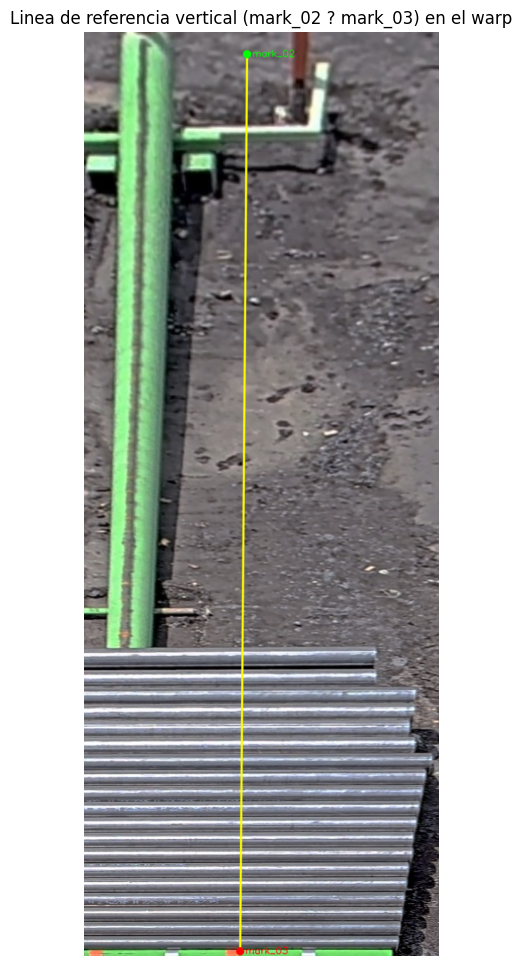

In [ ]:
import cv2
import numpy as np

def _warp_xy_local(x_src, y_src):
    if 'source_xy_for_processing' not in globals():
        raise RuntimeError('Falta source_xy_for_processing en el kernel. Recorre la celda de homografia.')
    if 'final_transform' not in globals():
        raise RuntimeError('Falta final_transform en el kernel. Recorre la celda de homografia.')
    x_proc, y_proc = source_xy_for_processing(x_src, y_src)
    pt = np.array([[[float(x_proc), float(y_proc)]]], dtype=np.float32)
    return cv2.perspectiveTransform(pt, final_transform).reshape(-1)

ref_top_src = next((p for p in points if p.get('label') == 'mark_02'), None)
ref_bot_src  = next((p for p in points if p.get('label') == 'mark_03'), None)

if ref_top_src is None or ref_bot_src is None:
    print('FALTAN puntos mark_02 y/o mark_03 en el TOML.')
    ref_top_w = ref_bot_w = None
else:
    ref_top_w = _warp_xy_local(ref_top_src['x'], ref_top_src['y'])
    ref_bot_w  = _warp_xy_local(ref_bot_src['x'],  ref_bot_src['y'])
    print(f"mark_02 src=({ref_top_src['x']}, {ref_top_src['y']})  ?  warp=({ref_top_w[0]:.1f}, {ref_top_w[1]:.1f})")
    print(f"mark_03 src=({ref_bot_src['x']},  {ref_bot_src['y']})  ?  warp=({ref_bot_w[0]:.1f},  {ref_bot_w[1]:.1f})")

    ref_vis = warp_bgr.copy()
    tw = (int(round(ref_top_w[0])), int(round(ref_top_w[1])))
    bw = (int(round(ref_bot_w[0])),  int(round(ref_bot_w[1])))
    cv2.line(ref_vis, tw, bw, (0, 255, 255), 2, cv2.LINE_AA)
    cv2.circle(ref_vis, tw, 6, (0, 255, 0), -1, cv2.LINE_AA)
    cv2.circle(ref_vis, bw,  6, (0, 0, 255), -1, cv2.LINE_AA)
    cv2.putText(ref_vis, 'mark_02', (tw[0] + 8, tw[1] + 4),  cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)
    cv2.putText(ref_vis, 'mark_03', (bw[0]  + 8, bw[1]  + 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
    show_bgr(ref_vis, 'Linea de referencia vertical (mark_02 ? mark_03) en el warp', figsize=(8, 12))


## 10. Distancia de Cada Tubo a la Linea de Referencia

Para cada tubo se interpola la posicion x de la linea de referencia a la altura detectada por Sobel X y se calcula `offset_px = x_start - ref_x`. Dividiendo por `px_per_in` obtenemos la distancia en pulgadas.

La medicion usa `raw_pick_x_positions`, que son los mismos puntos dibujados en `roi_overlay_vis`. `raw_x_positions` queda como version suavizada de referencia y se muestra en la tabla, pero no reemplaza al punto crudo medido. La numeracion de tubos es siempre de abajo hacia arriba: tubo 1 es el inferior.

In [ ]:
if ref_top_w is None or ref_bot_w is None:
    print('Saltando: faltan puntos de referencia.')
elif px_per_in_nb is None:
    print('Saltando: no hay escala px/in disponible.')
else:
    # Offset del crop al espacio warp_bgr.
    crop_x0 = int(detection_roi[0])
    crop_y0 = int(detection_roi[1])

    def ref_x_at_y(y_warp):
        """Interpola la x de la linea ref_01 a la altura y en el warp_bgr."""
        x0r, y0r = float(ref_top_w[0]), float(ref_top_w[1])
        x1r, y1r = float(ref_bot_w[0]),  float(ref_bot_w[1])
        if abs(y1r - y0r) <= 1e-6:
            return 0.5 * (x0r + x1r)
        t = (float(y_warp) - y0r) / (y1r - y0r)
        return x0r + t * (x1r - x0r)

    def _as_float_list(values):
        if values is None:
            return []
        return [float(v) for v in np.asarray(values).reshape(-1).tolist()]

    def _as_int_list(values):
        if values is None:
            return []
        return [int(round(float(v))) for v in np.asarray(values).reshape(-1).tolist()]

    def _value_at(seq, pos):
        return seq[pos] if 0 <= pos < len(seq) else None

    # Usar los mismos puntos crudos que se dibujaron en roi_overlay_vis.
    # raw_x_positions queda suavizado al final del paso Sobel X; se conserva solo como referencia.
    _probe_rows = _as_int_list(probe_rows)
    _x_raw = _as_float_list(globals().get('raw_pick_x_positions', globals().get('raw_x_positions', [])))
    _x_smooth = _as_float_list(globals().get('raw_x_positions', []))
    _roi_boxes = list(globals().get('roi_boxes', []))
    _n_expected = max(len(_probe_rows), len(_x_raw), len(_x_smooth), len(_roi_boxes))

    _numbering_rows = []
    for _pos in range(_n_expected):
        _y_for_number = _value_at(_probe_rows, _pos)
        if _y_for_number is None and _pos < len(_roi_boxes):
            _y0_num, _y1_num = _roi_boxes[_pos]
            _y_for_number = 0.5 * (float(_y0_num) + float(_y1_num))
        _numbering_rows.append((_pos, float(_y_for_number) if _y_for_number is not None else float('-inf')))
    _tube_number_by_pos = {
        int(pos): int(rank)
        for rank, (pos, _y) in enumerate(sorted(_numbering_rows, key=lambda item: item[1], reverse=True), start=1)
    }

    print('conteos:')
    print('  roi_boxes =', len(_roi_boxes))
    print('  raw_pick_x_positions =', len(_x_raw))
    print('  raw_x_positions_suavizado =', len(_x_smooth))
    print('  probe_rows =', len(_probe_rows))
    print('  numeracion = abajo -> arriba')
    if len({len(_probe_rows), len(_x_raw), len(_roi_boxes)} - {0}) > 1:
        print('Aviso: hay longitudes distintas; se medira todo punto con x/y disponible y se reportaran omitidos.')

    # Calcular medicion por tubo sin truncar silenciosamente con zip().
    tube_measurements = []
    skipped_measurements = []
    for pos in range(_n_expected):
        idx = int(_tube_number_by_pos.get(pos, _n_expected - pos))
        y_crop = _value_at(_probe_rows, pos)
        x_crop_raw = _value_at(_x_raw, pos)
        x_crop_smooth = _value_at(_x_smooth, pos)
        if y_crop is None or (x_crop_raw is None and x_crop_smooth is None):
            skipped_measurements.append(idx)
            continue

        # La distancia usa x_crop_raw porque es el punto que se vio en roi_overlay_vis.
        # Si no existe por compatibilidad con celdas viejas, se usa el suavizado.
        x_crop = x_crop_raw if x_crop_raw is not None else x_crop_smooth
        x_warp = float(x_crop) + crop_x0
        y_warp = float(y_crop) + crop_y0
        rx = ref_x_at_y(y_warp)
        offset_px = x_warp - rx
        dist_in = abs(offset_px) / px_per_in_nb
        tube_measurements.append({
            'tube_idx': idx,
            'x_start_warp': float(x_warp),
            'x_start_raw_warp': float(x_warp),
            'x_start_smooth_warp': None if x_crop_smooth is None else float(x_crop_smooth) + crop_x0,
            'y_center_warp': float(y_warp),
            'ref_x': float(rx),
            'offset_px': float(offset_px),
            'distance_in': float(dist_in),
        })

    if skipped_measurements:
        print('Omitidos por falta de x/y:', skipped_measurements)

    tube_measurements = sorted(tube_measurements, key=lambda item: int(item['tube_idx']))


    _manual_app_dir = ARTIFACT_ROOT / str(IMG_PATH.stem) / 'manual_measure_app'
    _manual_app_dir.mkdir(parents=True, exist_ok=True)
    _manual_app_img_path = _manual_app_dir / 'analysis_warp_current.jpg'
    cv2.imwrite(str(_manual_app_img_path), warp_bgr)

    from src.cam151_ref_detection.tube_matcher_proc import export_tube_measurements

    tube_measurements_export_path = export_tube_measurements(
        '151',
        tube_measurements,
        image_path=str(IMG_PATH),
        roi_path=str(ROI_PATH),
        source_notebook='tube_detection_step_by_step_cam151.ipynb',
        dataset_name='cam151',
        extra_meta={
            'px_per_in_nb': None if px_per_in_nb is None else float(px_per_in_nb),
            'scale_samples': [
                {
                    'label': str(s['label']),
                    'distance_in': float(s['distance_in']),
                    'distance_px': float(s['distance_px']),
                    'px_per_in': float(s['px_per_in']),
                    'p1_warp': [float(v) for v in s['p1_warp']],
                    'p2_warp': [float(v) for v in s['p2_warp']],
                }
                for s in scale_samples_nb
            ],
            'detection_roi': [float(v) for v in np.asarray(detection_roi).reshape(-1).tolist()],
            'reference_line_warp': {
                'mark_02': None if ref_top_w is None else [float(ref_top_w[0]), float(ref_top_w[1])],
                'mark_03': None if ref_bot_w is None else [float(ref_bot_w[0]), float(ref_bot_w[1])],
            },
            'analysis_image_path': str(_manual_app_img_path),
        },
        output_dir=ROOT / 'artifacts' / 'tube_matcher_inputs',
    )
    print(f'Exportado para app manual: {tube_measurements_export_path}')

    # Tabla.
    print(f"{'tubo':>5}  {'x_raw':>8}  {'x_smooth':>8}  {'ref_x':>7}  {'offset_px':>10}  {'dist_in':>9}")
    print('-' * 62)
    for m in tube_measurements:
        x_smooth_txt = 'NA' if m['x_start_smooth_warp'] is None else f"{m['x_start_smooth_warp']:.1f}"
        print(f"{m['tube_idx']:>5}  {m['x_start_raw_warp']:>8.1f}  {x_smooth_txt:>8}  {m['ref_x']:>7.1f}  {m['offset_px']:>10.2f}  {m['distance_in']:>9.3f}")

    # Visualizacion sobre el warp completo.
    dist_vis = warp_bgr.copy()

    # Cajas ROI usadas por Sobel X, para comparar contra roi_overlay_vis.
    if _roi_boxes:
        for idx, (y0, y1) in enumerate(_roi_boxes, start=1):
            y0i = int(round(float(y0))) + crop_y0
            y1i = int(round(float(y1))) + crop_y0
            x0i = int(x_search0) + crop_x0
            x1i = int(x_search1) - 1 + crop_x0
            cv2.rectangle(dist_vis, (x0i, y0i), (x1i, y1i), (0, 170, 255), 1, cv2.LINE_AA)
            tube_number = int(_tube_number_by_pos.get(idx - 1, len(_roi_boxes) - idx + 1))
            cv2.putText(dist_vis, str(tube_number), (x0i + 4, max(12, y0i + 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1, cv2.LINE_AA)

    # Costuras verdes.
    for p in peaks_filled:
        cv2.line(dist_vis, (0, int(p) + crop_y0), (dist_vis.shape[1] - 1, int(p) + crop_y0), (0, 180, 60), 1)

    # Linea de referencia.
    tw = (int(round(ref_top_w[0])), int(round(ref_top_w[1])))
    bw = (int(round(ref_bot_w[0])),  int(round(ref_bot_w[1])))
    cv2.line(dist_vis, tw, bw, (0, 255, 255), 2, cv2.LINE_AA)

    # Segmento por tubo.
    for m in tube_measurements:
        rx = int(round(m['ref_x']))
        xs = int(round(m['x_start_warp']))
        yc = int(round(m['y_center_warp']))
        cv2.line(dist_vis, (rx, yc), (xs, yc), (255, 140, 0), 1, cv2.LINE_AA)
        cv2.circle(dist_vis, (xs, yc), 3, (0, 255, 255), -1, cv2.LINE_AA)
        if m['x_start_smooth_warp'] is not None:
            xs_s = int(round(m['x_start_smooth_warp']))
            if abs(xs_s - xs) >= 2:
                cv2.circle(dist_vis, (xs_s, yc), 2, (255, 0, 255), -1, cv2.LINE_AA)
        label_text = f"{m['distance_in']:.1f} in"
        label_x = min(rx, xs) + max(2, abs(xs - rx) // 4)
        label_y = yc - 5
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.34
        thickness = 1
        (txt_w, txt_h), baseline = cv2.getTextSize(label_text, font, font_scale, thickness)
        pad_x, pad_y = 3, 2
        box_x0 = max(0, min(dist_vis.shape[1] - txt_w - 2 * pad_x - 1, int(label_x)))
        box_y0 = max(0, min(dist_vis.shape[0] - txt_h - 2 * pad_y - baseline - 1, int(label_y - txt_h - pad_y)))
        box_x1 = box_x0 + txt_w + 2 * pad_x
        box_y1 = box_y0 + txt_h + 2 * pad_y + baseline
        cv2.rectangle(dist_vis, (box_x0, box_y0), (box_x1, box_y1), (225, 232, 238), -1, cv2.LINE_AA)
        cv2.rectangle(dist_vis, (box_x0, box_y0), (box_x1, box_y1), (145, 155, 165), 1, cv2.LINE_AA)
        cv2.putText(dist_vis, label_text,
                    (box_x0 + pad_x, box_y0 + pad_y + txt_h), font, font_scale, (105, 82, 55), thickness, cv2.LINE_AA)
    show_bgr(dist_vis, 'Distancia de cada tubo a la linea de referencia (mark_02 -> mark_03)', figsize=(8, 12))
